In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import datetime

In [ ]:
sales = pd.read_excel('data/sales.xlsx')
sales.head()

,InvoiceNumber,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerId,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df_no_missing_CustomerId = sales.copy()
df_no_missing_CustomerId = df_no_missing_CustomerId[df_no_missing_CustomerId['CustomerId'] != 'NaN'].dropna(subset=['CustomerId']) 

df_no_missing_CustomerId.head()

,InvoiceNumber,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerId,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df_no_duplicate = df_no_missing_CustomerId.copy()
df_no_duplicate = df_no_duplicate.drop_duplicates()

df_no_duplicate.head()

,InvoiceNumber,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerId,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df_no_missing_price = df_no_duplicate.copy()
df_no_missing_price = df_no_missing_price[df_no_missing_price['UnitPrice'] > 0]

df_no_missing_price.head()

,InvoiceNumber,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerId,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
percentage_cancelled_orders = round((df_no_missing_price[df_no_missing_price['InvoiceNumber'].astype(str).str.startswith('C')]['InvoiceNumber'].nunique() / df_no_missing_price['InvoiceNumber'].nunique()) * 100)

In [7]:
top_cancelling_customers = df_no_missing_price[df_no_missing_price['InvoiceNumber'].astype(str).str.startswith('C')][['CustomerId', 'InvoiceNumber']].drop_duplicates().groupby('CustomerId').count().sort_values('InvoiceNumber', ascending=False).head(5).index.astype(str).tolist()

In [8]:
df_no_canceled_invoice = df_no_missing_price.copy()
df_no_canceled_invoice = df_no_missing_price[~df_no_missing_price['InvoiceNumber'].astype(str).str.startswith('C')]

df_no_canceled_invoice.head()

,InvoiceNumber,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerId,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [15]:
preprocessed_sales = df_no_canceled_invoice.copy()
preprocessed_sales.head()

,InvoiceNumber,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerId,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
remaining_invoices = pd.Series(df_no_missing_price[~df_no_missing_price['InvoiceNumber'].astype(str).str.startswith('C')]['InvoiceNumber'].unique())

In [11]:
number_of_orders = preprocessed_sales['InvoiceNumber'].nunique()

In [12]:
window_period = (preprocessed_sales['InvoiceDate'].min(), preprocessed_sales['InvoiceDate'].max())

/tmp/ipykernel_1052781/2793364710.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax1.bar(["Mon", "Tue", "Wed", "Thur", "Fri", "Sat", "Sun"], preprocessed_sales.groupby('DayName')['InvoiceNumber'].nunique() , color='lime');
/tmp/ipykernel_1052781/2793364710.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax1.set_ylim(0, preprocessed_sales.groupby('DayName')['InvoiceDate'].nunique().max() * 1.14);


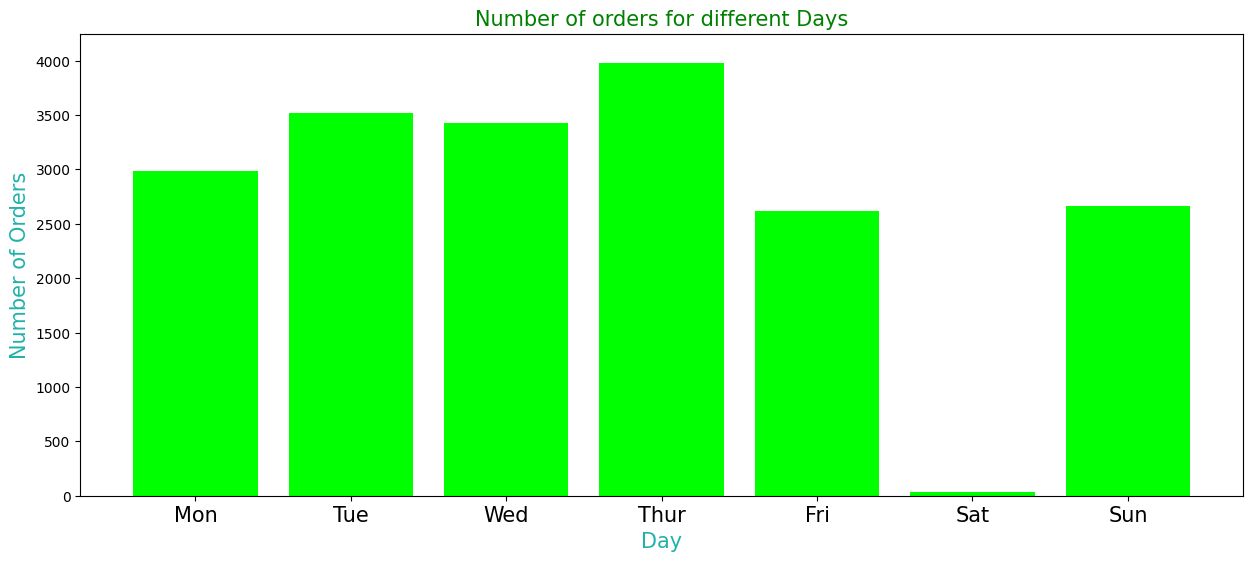

In [18]:
fig1, ax1 = plt.subplots(figsize = (15,6))
ax1.set_title("Number of orders for different Days", fontsize=15, color = 'green')
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
preprocessed_sales['DayName'] = pd.to_datetime(preprocessed_sales['InvoiceDate']).dt.day_name().str[:3]
preprocessed_sales['DayName'] = pd.Categorical(preprocessed_sales['DayName'], categories=days);
ax1.bar(["Mon", "Tue", "Wed", "Thur", "Fri", "Sat", "Sun"], preprocessed_sales.groupby('DayName')['InvoiceNumber'].nunique() , color='lime');
plt.xticks(fontsize=15);
ax1.set_xlabel("Day", color = 'lightseagreen', fontsize = 15);
ax1.set_ylabel("Number of Orders", color = 'lightseagreen', fontsize = 15);
ax1.set_ylim(0, preprocessed_sales.groupby('DayName')['InvoiceDate'].nunique().max() * 1.14);

<BarContainer object of 13 artists>

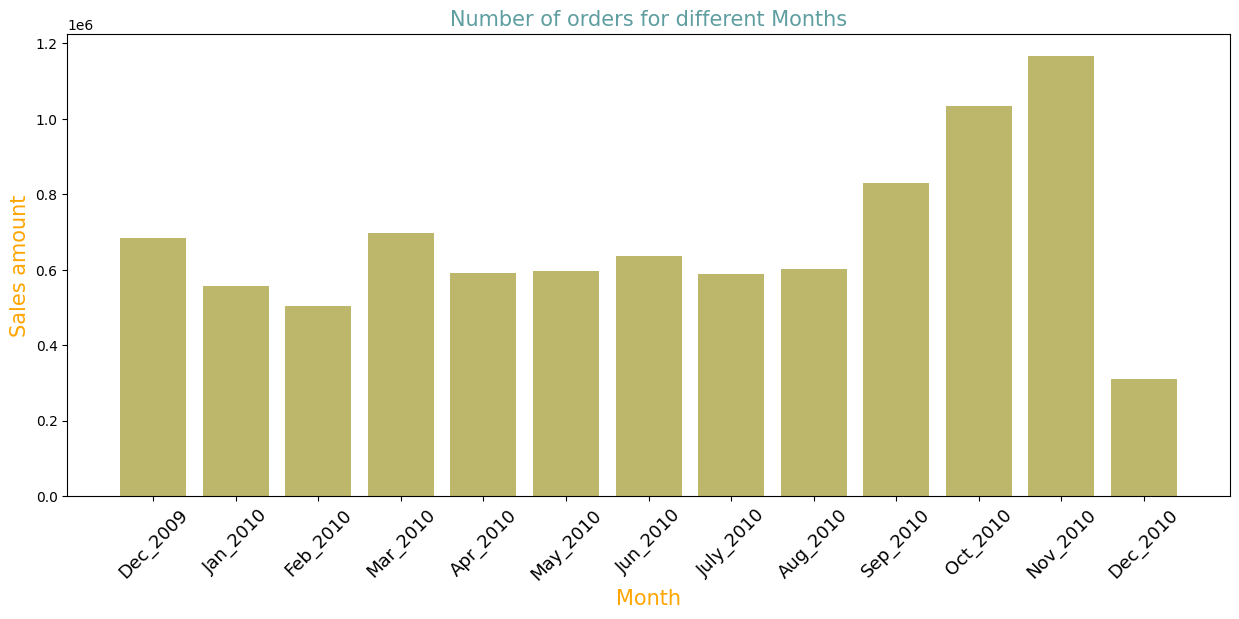

In [16]:
fig2, ax2 = plt.subplots(figsize = (15,6));
ax2.set_title("Number of orders for different Months", fontsize=15, color = 'cadetblue')
ax2.set_xlabel("Month", color = 'orange', fontsize = 15);
ax2.set_ylabel("Sales amount", color = 'orange', fontsize = 15);
plt.xticks(rotation=45, fontsize = 13);
preprocessed_sales['SalesAmount'] = preprocessed_sales['UnitPrice'] * preprocessed_sales['Quantity']
preprocessed_sales['InvoiceDate'] = pd.to_datetime( preprocessed_sales['InvoiceDate'])
preprocessed_sales['Month_year'] = preprocessed_sales['InvoiceDate'].apply(lambda x: f"July_{x.year}" if x.month == 7 else f"{x.strftime('%b')}_{x.year}")
monthly_sales = preprocessed_sales.groupby('Month_year')['SalesAmount'].sum().reset_index()
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
months_dict = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,'July': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
monthly_sales[['Month_str', 'Year']] = monthly_sales['Month_year'].str.split('_', expand=True)
monthly_sales['Year'] = monthly_sales['Year'].astype(int)
monthly_sales['Month_num'] = monthly_sales['Month_str'].map(months_dict)
monthly_sales = monthly_sales.sort_values(['Year', 'Month_num'])
categories_order = monthly_sales['Month_year'].unique()
monthly_sales['Month_year'] = pd.Categorical(monthly_sales['Month_year'],categories=categories_order,ordered=True)
ax2.bar(monthly_sales['Month_year'], monthly_sales['SalesAmount'], color='darkkhaki')

In [20]:
df = preprocessed_sales.drop(preprocessed_sales[preprocessed_sales["Country"] == "United Kingdom"].index)
df["Total"] = df["Quantity"] * df["UnitPrice"]
country = df.groupby("Country").agg(UniqueCustomers=("CustomerId", "nunique"),TotalSales=("Total", "sum"))
qCC = country["UniqueCustomers"].quantile(0.75)
qSA = country["TotalSales"].quantile(0.75)
def assign_group(row):
    cc = row["UniqueCustomers"]
    sa = row["TotalSales"]
    if cc > qCC and sa > qSA:
        return "red"
    elif cc > qCC and sa <= qSA:
        return "blue"
    elif cc <= qCC and sa > qSA:
        return "green"
    else:
        return "cyan"
country["Color"] = country.apply(assign_group, axis=1)
country.head()

,UniqueCustomers,TotalSales,Color
Country,,,
Australia,15,31446.80,red
Austria,10,13414.33,cyan
Bahrain,2,805.97,cyan
Belgium,17,24537.58,blue
Brazil,1,268.27,cyan


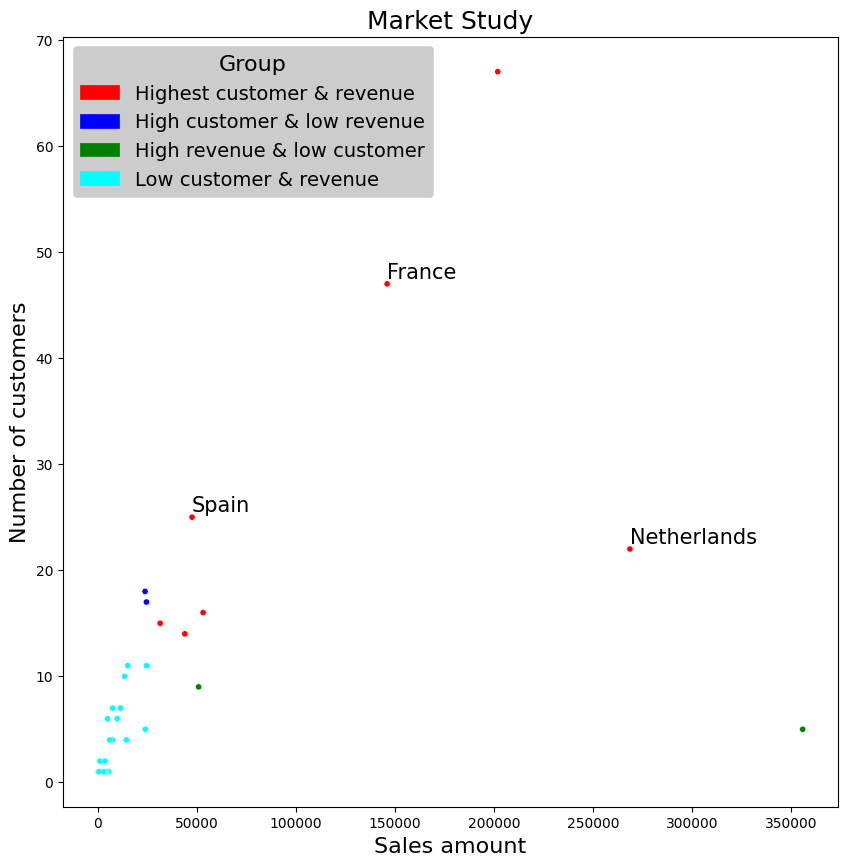

In [21]:
fig , ax = plt.subplots(figsize = (10,10));
ax.set_title("Market Study", fontsize = 18 );
plt.style.use('fivethirtyeight');

sns.scatterplot(data=country,x="TotalSales",y="UniqueCustomers",hue="Color",palette={"red": "red", "blue": "blue", "green": "green", "cyan": "cyan"},s=20);

plt.ylabel("Number of customers", fontsize = 16)
plt.xlabel("Sales amount", fontsize = 16)

legend_elements = [mpatches.Patch(color='red',   label='Highest customer & revenue'),mpatches.Patch(color='blue',  label='High customer & low revenue'),mpatches.Patch(color='green', label='High revenue & low customer'),mpatches.Patch(color='cyan',  label='Low customer & revenue')]
target_countries = ["France", "Spain", "Netherlands"]
country_filtered = country[country.index.isin(target_countries)]
for country_name, row in country_filtered.iterrows():
    ax.text(x=row["TotalSales"],y=row["UniqueCustomers"] + 0.5,s=country_name,fontsize=15)

plt.legend(handles=legend_elements, title="Group", loc="best", frameon=True, facecolor='silver', title_fontsize = 16, prop={'size': 14})

In [22]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
last_day = df['InvoiceDate'].max() + pd.Timedelta(days=1)
last_day

Timestamp('2010-12-10 14:55:00')

In [23]:
df_customer_segments = df.groupby('CustomerId')['InvoiceDate'].max().reset_index()
df_customer_segments = df_customer_segments.rename(columns={'InvoiceDate': 'LastPurchaseDate'})
df_customer_segments['Recency'] = (last_day - df_customer_segments['LastPurchaseDate']).dt.days
df_customer_segments = df_customer_segments.sort_values('CustomerId').reset_index(drop=True)
df_customer_segments.head()

,CustomerId,LastPurchaseDate,Recency
0,12347.0,2010-12-07 14:57:00,2
1,12348.0,2010-09-27 14:59:00,73
2,12349.0,2010-10-28 08:23:00,43
3,12351.0,2010-11-29 15:23:00,10
4,12352.0,2010-11-29 10:07:00,11


In [24]:
frequency = df.groupby('CustomerId')['InvoiceNumber'].nunique().reset_index(name='Frequency')
df_customer_segments['Frequency'] = df_customer_segments.merge(frequency, on='CustomerId', how='left')['Frequency']
df_customer_segments.head()

,CustomerId,LastPurchaseDate,Recency,Frequency
0,12347.0,2010-12-07 14:57:00,2,2
1,12348.0,2010-09-27 14:59:00,73,1
2,12349.0,2010-10-28 08:23:00,43,3
3,12351.0,2010-11-29 15:23:00,10,1
4,12352.0,2010-11-29 10:07:00,11,2


In [25]:
df_customer_segments['MonetaryValue'] = df.groupby('CustomerId').apply(lambda g: (g['UnitPrice'] * g['Quantity']).sum()).reindex(df_customer_segments['CustomerId']).values
df_customer_segments.head()

/tmp/ipykernel_1052781/1233637390.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_customer_segments['MonetaryValue'] = df.groupby('CustomerId').apply(lambda g: (g['UnitPrice'] * g['Quantity']).sum()).reindex(df_customer_segments['CustomerId']).values


,CustomerId,LastPurchaseDate,Recency,Frequency,MonetaryValue
0,12347.0,2010-12-07 14:57:00,2,2,1323.32
1,12348.0,2010-09-27 14:59:00,73,1,222.16
2,12349.0,2010-10-28 08:23:00,43,3,2671.14
3,12351.0,2010-11-29 15:23:00,10,1,300.93
4,12352.0,2010-11-29 10:07:00,11,2,343.80


In [26]:
q1, q2, q3 = df_customer_segments['Recency'].quantile([0.25, 0.5, 0.75])
conditions = [
    (df_customer_segments['Recency'] <= q1),
    (df_customer_segments['Recency'] > q1) & (df_customer_segments['Recency'] <= q2),
    (df_customer_segments['Recency'] > q2) & (df_customer_segments['Recency'] <= q3),
    (df_customer_segments['Recency'] > q3)
]
choices = [1, 2, 3, 4]
df_customer_segments['R_quartile'] = np.select(conditions, choices)

q1, q2, q3 = df_customer_segments['Frequency'].quantile([0.25, 0.5, 0.75])
conditions = [
    (df_customer_segments['Frequency'] <= q1),
    (df_customer_segments['Frequency'] > q1) & (df_customer_segments['Frequency'] <= q2),
    (df_customer_segments['Frequency'] > q2) & (df_customer_segments['Frequency'] <= q3),
    (df_customer_segments['Frequency'] > q3)
]
df_customer_segments['F_quartile'] = np.select(conditions, choices)

q1, q2, q3 = df_customer_segments['MonetaryValue'].quantile([0.25, 0.5, 0.75])
conditions = [
    (df_customer_segments['MonetaryValue'] <= q1),
    (df_customer_segments['MonetaryValue'] > q1) & (df_customer_segments['MonetaryValue'] <= q2),
    (df_customer_segments['MonetaryValue'] > q2) & (df_customer_segments['MonetaryValue'] <= q3),
    (df_customer_segments['MonetaryValue'] > q3)
]
df_customer_segments['M_quartile'] = np.select(conditions, choices)

df_customer_segments.head()

,CustomerId,LastPurchaseDate,Recency,Frequency,MonetaryValue,R_quartile,F_quartile,M_quartile
0,12347.0,2010-12-07 14:57:00,2,2,1323.32,1,2,3
1,12348.0,2010-09-27 14:59:00,73,1,222.16,3,1,1
2,12349.0,2010-10-28 08:23:00,43,3,2671.14,2,3,4
3,12351.0,2010-11-29 15:23:00,10,1,300.93,1,1,1
4,12352.0,2010-11-29 10:07:00,11,2,343.80,1,2,1


In [27]:
df_customer_segments['RFM'] = df_customer_segments['R_quartile'].astype(str) + df_customer_segments['F_quartile'].astype(str) + df_customer_segments['M_quartile'].astype(str)
df_customer_segments.head()

,CustomerId,LastPurchaseDate,Recency,Frequency,MonetaryValue,R_quartile,F_quartile,M_quartile,RFM
0,12347.0,2010-12-07 14:57:00,2,2,1323.32,1,2,3,123
1,12348.0,2010-09-27 14:59:00,73,1,222.16,3,1,1,311
2,12349.0,2010-10-28 08:23:00,43,3,2671.14,2,3,4,234
3,12351.0,2010-11-29 15:23:00,10,1,300.93,1,1,1,111
4,12352.0,2010-11-29 10:07:00,11,2,343.80,1,2,1,121


In [ ]:
def assign_segment(rfm):
    rfm_str = str(rfm)
    if rfm_str == '144':
        return 'Best'
    elif rfm_str == '344':
        return 'AlmostLost'
    elif rfm_str == '444':
        return 'LostBigSpenders'
    elif rfm_str == '441':
        return 'LostCheap'
    elif rfm_str[1] == '4': 
        return 'Loyal'
    elif rfm_str[2] == '4': 
        return 'BigSpenders'
    else:
        return 'Normal'
df_customer_segments['Segment'] = df_customer_segments['RFM'].astype(str).apply(assign_segment)
df_customer_segments.head()

,CustomerId,LastPurchaseDate,Recency,Frequency,MonetaryValue,R_quartile,F_quartile,M_quartile,RFM,Segment
0,12347.0,2010-12-07 14:57:00,2,2,1323.32,1,2,3,123,Normal
1,12348.0,2010-09-27 14:59:00,73,1,222.16,3,1,1,311,Normal
2,12349.0,2010-10-28 08:23:00,43,3,2671.14,2,3,4,234,BigSpenders
3,12351.0,2010-11-29 15:23:00,10,1,300.93,1,1,1,111,Normal
4,12352.0,2010-11-29 10:07:00,11,2,343.80,1,2,1,121,Normal


In [30]:
df['InvoiceMonth'] = df['InvoiceDate'].apply(lambda x: datetime.datetime(x.year, x.month, 1))
df['CohortMonth'] = df.groupby('CustomerId')['InvoiceMonth'].transform('min')

df.head()

,InvoiceNumber,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerId,Country,SalesAmount,Month_year,DayName,Total,InvoiceMonth,CohortMonth
71,489439,22065,CHRISTMAS PUDDING TRINKET POT,12,2009-12-01 09:28:00,1.45,12682.0,France,17.40,Dec_2009,Tue,17.40,2009-12-01,2009-12-01
72,489439,22138,BAKING SET 9 PIECE RETROSPOT,9,2009-12-01 09:28:00,4.95,12682.0,France,44.55,Dec_2009,Tue,44.55,2009-12-01,2009-12-01
73,489439,22139,RETRO SPOT TEA SET CERAMIC 11 PC,9,2009-12-01 09:28:00,4.95,12682.0,France,44.55,Dec_2009,Tue,44.55,2009-12-01,2009-12-01
74,489439,22352,LUNCHBOX WITH CUTLERY RETROSPOT,12,2009-12-01 09:28:00,2.55,12682.0,France,30.60,Dec_2009,Tue,30.60,2009-12-01,2009-12-01
75,489439,85014A,BLACK/BLUE DOTS RUFFLED UMBRELLA,3,2009-12-01 09:28:00,5.95,12682.0,France,17.85,Dec_2009,Tue,17.85,2009-12-01,2009-12-01


In [31]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month  = get_date_int(df, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

df['CohortIndex'] = years_diff * 12 + months_diff + 1

df[['CohortMonth', 'CohortIndex']]

,CohortMonth,CohortIndex
71,2009-12-01,1
72,2009-12-01,1
73,2009-12-01,1
74,2009-12-01,1
75,2009-12-01,1
...,...,...
524541,2010-10-01,3
524542,2010-10-01,3
524543,2010-10-01,3
524544,2010-10-01,3


In [32]:
grouping = df.groupby(['CohortMonth', 'CohortIndex'])
cohort_data = grouping['CustomerId'].apply(pd.Series.nunique)
cohort_data = cohort_data.reset_index()

cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerId')

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12-01,51.0,19.0,21.0,24.0,21.0,20.0,24.0,16.0,17.0,26.0,24.0,27.0,14.0
2010-01-01,38.0,7.0,9.0,9.0,10.0,5.0,12.0,7.0,12.0,10.0,10.0,3.0,NaN
2010-02-01,31.0,9.0,8.0,5.0,9.0,4.0,9.0,9.0,7.0,9.0,2.0,NaN,NaN
2010-03-01,31.0,3.0,4.0,5.0,6.0,3.0,5.0,8.0,6.0,1.0,NaN,NaN,NaN
2010-04-01,25.0,5.0,2.0,3.0,3.0,7.0,7.0,7.0,3.0,NaN,NaN,NaN,NaN
2010-05-01,21.0,4.0,3.0,3.0,3.0,6.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN
2010-06-01,24.0,5.0,3.0,4.0,6.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,23.0,4.0,6.0,6.0,8.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,13.0,2.0,4.0,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention = retention * 100

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12-01,100.0,37.254902,41.176471,47.058824,41.176471,39.215686,47.058824,31.372549,33.333333,50.980392,47.058824,52.941176,27.45098
2010-01-01,100.0,18.421053,23.684211,23.684211,26.315789,13.157895,31.578947,18.421053,31.578947,26.315789,26.315789,7.894737,NaN
2010-02-01,100.0,29.032258,25.806452,16.129032,29.032258,12.903226,29.032258,29.032258,22.580645,29.032258,6.451613,NaN,NaN
2010-03-01,100.0,9.677419,12.903226,16.129032,19.354839,9.677419,16.129032,25.806452,19.354839,3.225806,NaN,NaN,NaN
2010-04-01,100.0,20.000000,8.000000,12.000000,12.000000,28.000000,28.000000,28.000000,12.000000,NaN,NaN,NaN,NaN
2010-05-01,100.0,19.047619,14.285714,14.285714,14.285714,28.571429,9.523810,9.523810,NaN,NaN,NaN,NaN,NaN
2010-06-01,100.0,20.833333,12.500000,16.666667,25.000000,25.000000,4.166667,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,100.0,17.391304,26.086957,26.086957,34.782609,8.695652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,100.0,15.384615,30.769231,53.846154,7.692308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Retention rates')

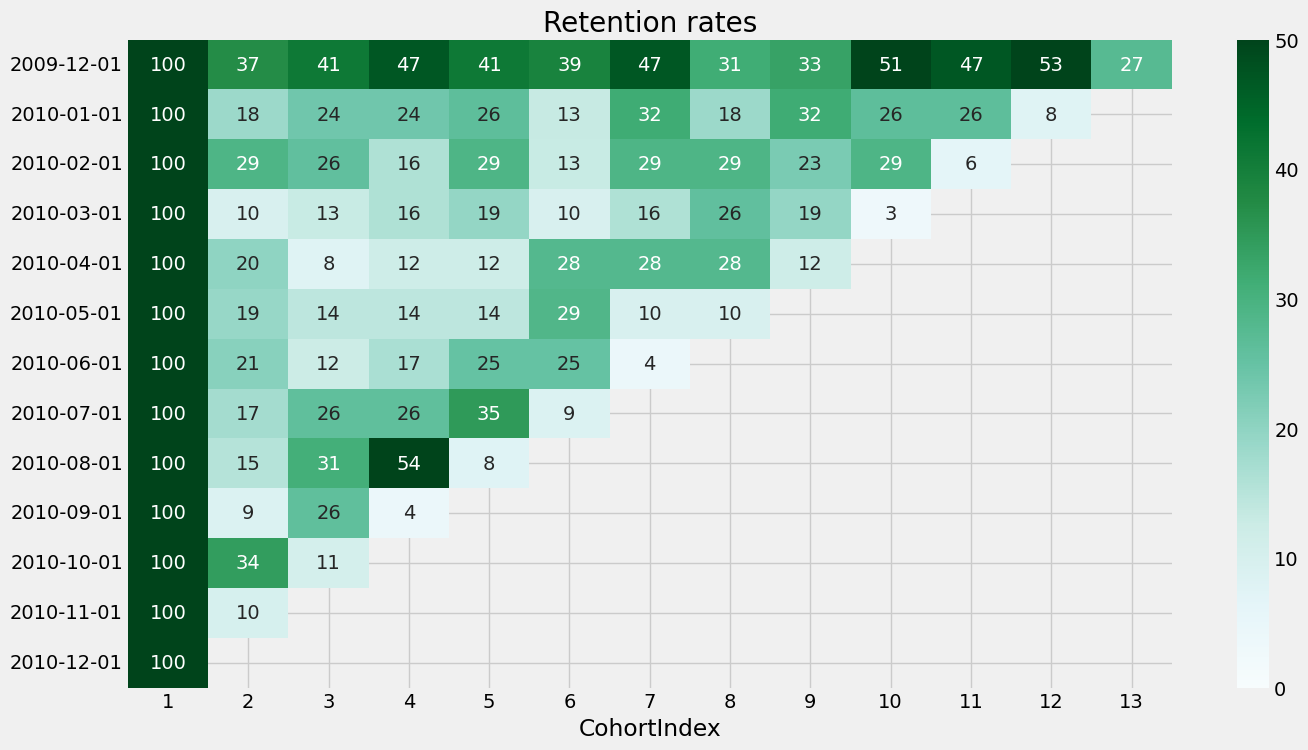

In [34]:
retention.index = retention.index.date

fig, ax = plt.subplots(figsize=(15, 8))

ax = sns.heatmap(data = retention, annot = True,
                 fmt=".0f",
                 vmin = 0,
                 vmax = 50,
                 cmap = 'BuGn'
                    )
ax.set_title("Retention rates")